In [1]:
# UCB ACQUISITION FUNCTION
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + (kappa * sigma)
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [2]:
import numpy as np
import pandas as pd

# Detect likely contamination sources in a two-dimensional area, such as a radiation field, 
# where only proximity yields a non-zero reading.
# The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

# Set random seed for reproducibility
np.random.seed(42)

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

# print('-- inputs X ---')
# print(X)
# print("X shape=",X.shape)

# print('-- outputs y ---')
# print(y)
# print("y shape=",y.shape)


week1_X = [0.828282, 0.777777]
week1_y = 1.6268381341133806e-44

X = np.vstack([X, week1_X])
y = np.append(y, week1_y)

df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

# Week1 result now in 3rd Place
# week1_X = [0.828282, 0.777777]
# week1_y = 1.6268381341133806e-44
# 10	0.828282	0.777777	1.626838e-44

,x1,x2,y
2,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
10,0.828282,0.777777,1.626838e-44
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
0,0.319404,0.762959,1.322677e-79
8,0.082507,0.403488,3.606771e-81
3,0.840353,0.264732,3.341771e-124
6,0.312691,0.078723,-2.089093e-91
5,0.410437,0.147554,-2.159249e-54


In [3]:
# Data clean up
# This is a error and it is masked
# 0.650114	0.681526	-3.606063e-03
size_limit = 1e-6
mask = y > -size_limit

X = X[mask]
y = y[mask]

# This two small negative are set to 0 - could be instrument measurement error
# 3	0.410437	0.147554	-2.159249e-54
# 4	0.650114	0.681526	-3.606063e-03

y[y < 0] = 0.0
eps = 1e-300   # far below any real signal
y_log = np.log(y + eps)

# This is a error and it is masked
# 0.650114	0.681526	-3.606063e-03
pit_location = [0.650114, 0.681526]


sorted_idx = np.argsort(y)[::-1]
best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

y_best_log = np.max(y_log)

print(sorted_idx)

print('----pit location--', pit_location)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y_best}")
print(f"Current Best log_y: {y_best_log}")

print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best}, y:{y_third_best}")

print('-- outputs y ---')
print(y_log)
print("y shape=",y.shape)


df_log = pd.DataFrame(X, columns=["x1","x2"])
df_log['y'] = y_log
df_log = df_log.sort_values(by='y', ascending=False)
df_log

[2 6 9 1 8 0 7 3 5 4]
----pit location-- [0.650114, 0.681526]
Current Best x_idx: 2
Current Best x: [0.73102363 0.73299988]
Current Best y: 7.710875114502849e-16
Current Best log_y: -34.798729802943996
Current 2nd Best x: [0.68341817 0.86105746], y:2.5350011535584046e-40
Current 3nd Best x: [0.828282 0.777777], y:1.6268381341133806e-44
-- outputs y ---
[-181.6245646  -105.88637135  -34.7987298  -284.31405062 -690.7755279
 -690.7755279   -91.17320963 -185.22657957 -108.69473117 -100.82710576]
y shape= (10,)


,x1,x2,y
2,0.731024,0.733000,-34.798730
6,0.683418,0.861057,-91.173210
9,0.828282,0.777777,-100.827106
1,0.574329,0.879898,-105.886371
8,0.883890,0.582254,-108.694731
0,0.319404,0.762959,-181.624565
7,0.082507,0.403488,-185.226580
3,0.840353,0.264732,-284.314051
4,0.410437,0.147554,-690.775528
5,0.312691,0.078723,-690.775528


In [4]:
import numpy as np
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
from scipy.stats import norm

warnings.filterwarnings('ignore', category=ConvergenceWarning)

# week1
# kernel = Matern(nu=2.5, length_scale_bounds=(0.1, 1.0))
# noise_assumption=1e-6
# gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=noise_assumption, n_restarts_optimizer=5)

# week2
kernel = (
    ConstantKernel(1.0, (1e-2, 1e2)) *   # signal variance
    Matern(
            length_scale=[0.15, 0.15],
            length_scale_bounds=(0.05, 0.25),
           nu=1.5) +
    WhiteKernel(noise_level=1e-4, noise_level_bounds="fixed")
)


gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X, y_log)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y_log)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Optimized Kernel: 0.764**2 * Matern(length_scale=[0.25, 0.25], nu=1.5) + WhiteKernel(noise_level=0.0001)
# Training R^2 Score: 0.9999999838286098
# Total variance accounted for as noise: 1e-10


Optimized Kernel: 0.764**2 * Matern(length_scale=[0.25, 0.25], nu=1.5) + WhiteKernel(noise_level=0.0001)
Training R^2 Score: 0.9999999838286098
Total variance accounted for as noise: 1e-10


In [5]:
# Create grid of potential X values
res=100
x_coord = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x_coord, x_coord)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Get predictions
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)

rmse = np.sqrt(np.mean((mu - y_log)**2))
print("Log-space RMSE:", rmse)

Log-space RMSE: 278.45319827563924


In [9]:
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"--- Optimization Results ---")
print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ucb_next_query}")

--- Optimization Results ---
UCB Score with kappa: 2.0
Current Best y: 7.710875114502849e-16
Suggested next: [0.5959596  0.63636364]


In [10]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best_log, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"--- Optimization Results ---")
print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ei_next_query}")

--- Optimization Results ---
expected_improvement with xi: 0.01
Current Best y: 7.710875114502849e-16
Suggested next: [0.63636364 0.67676768]


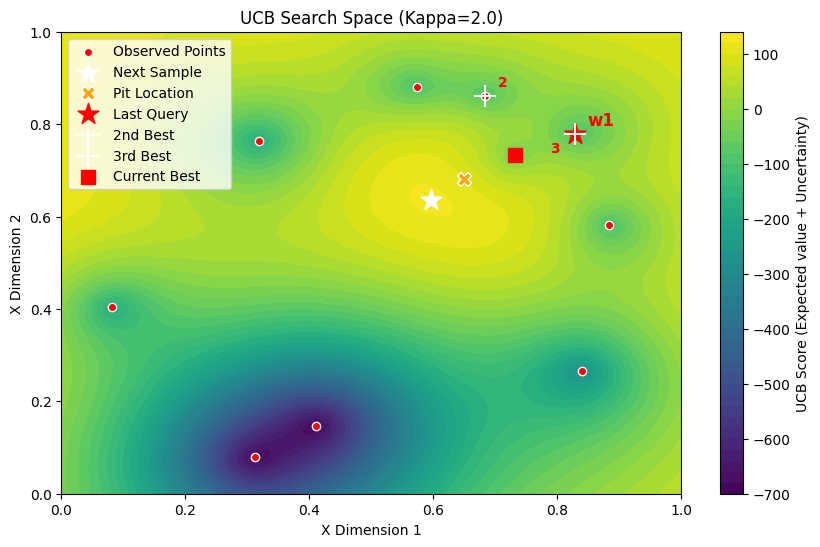

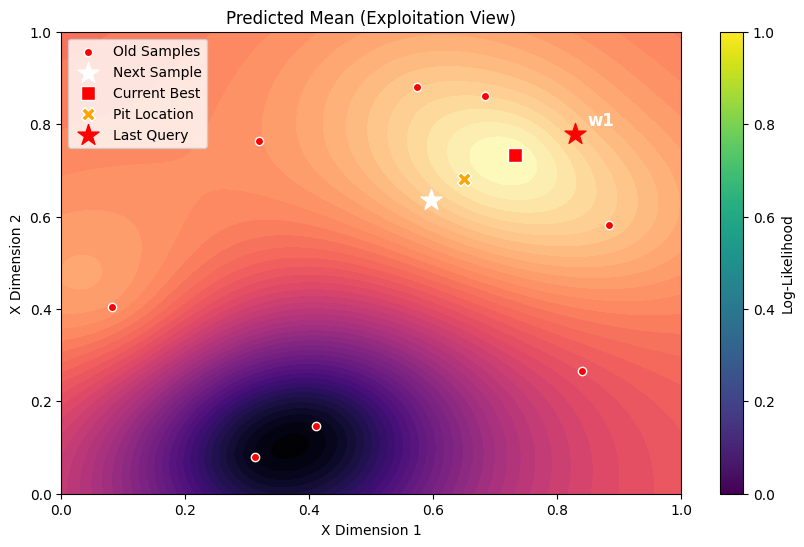

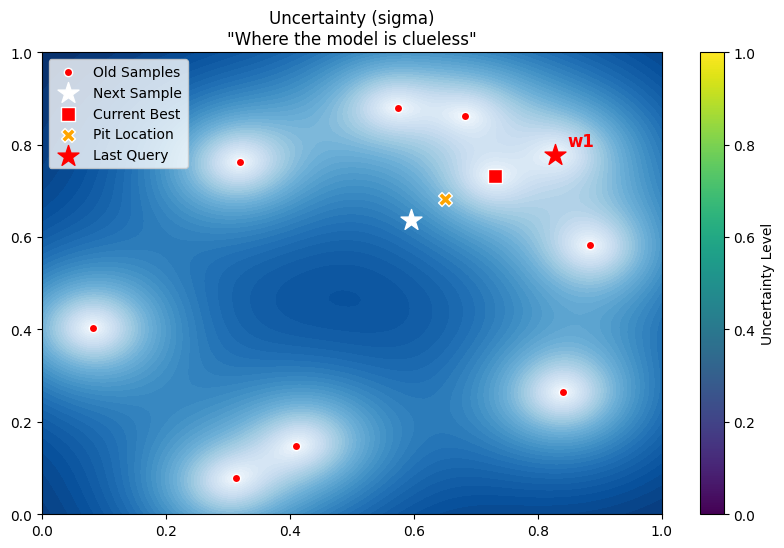

In [11]:
# UCB VISUALIZATION
ucb_map = ucb_values.reshape(res, res)
week1_query= week1_X

plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ucb_map, levels=50, cmap='viridis')
plt.colorbar(label='UCB Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')

plt.scatter(x_second_best[0], x_second_best[1], c='white', marker='+', s=250, label='2nd Best')
plt.text(x_second_best[0] + 0.02, x_second_best[1] + 0.02, '2', fontsize=10, fontweight='bold', color='red')

plt.scatter(x_third_best[0], x_third_best[1], c='white', marker='+', s=250, label='3rd Best')
plt.text(x_third_best[0] - 0.04, x_third_best[1] - 0.04, '3', fontsize=10, fontweight='bold', color='red')

plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', marker='s', s=100, label='Current Best')
plt.title(f"UCB Search Space (Kappa={kappa})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

mu_map = mu.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, mu_map, levels=50, cmap='magma')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='white')

plt.title('Predicted Mean (Exploitation View)')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

sigma_map = sigma.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, sigma_map, levels=50, cmap='Blues')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')

plt.title('Uncertainty (sigma)\n"Where the model is clueless"')
plt.colorbar(label='Uncertainty Level')
plt.legend()
plt.show()

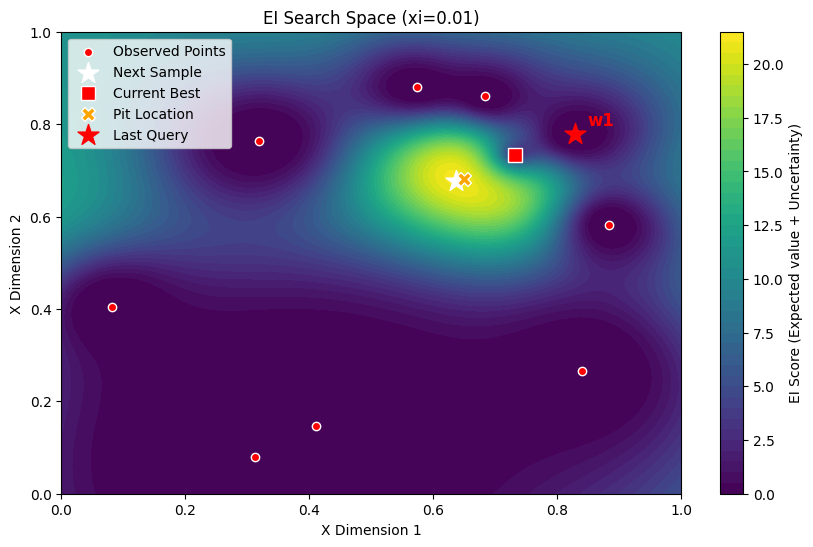

In [12]:
# EI VISUALIZATION
ei_map = ei_values.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ei_map, levels=50, cmap='viridis')
plt.colorbar(label='EI Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ei_next_query[0], ei_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')


plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')

plt.title(f"EI Search Space (xi={xi})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

In [13]:
# Observation
# --------Week2
# week1 result turns out be great and it is in the 3rd place 
# week1_X = [0.828282, 0.777777]
# week1_y = 1.6268381341133806e-44
# 10	0.828282	0.777777	1.626838e-44


# PIT removed
# This is a error and it is masked (Pit)
# 0.650114	0.681526	-3.606063e-03

# This two small negative are set to 0 - could be instrument measurement error
# 3	0.410437	0.147554	-2.159249e-54
# 4	0.650114	0.681526	-3.606063e-03

# - Pit removed
# - tiny negative reading turn to 0 (tiny positive for log to work)
# - run log of the y as the y is tiny and ranges are wide
# - run the BO
# - BO suggest both UCB/EI point next best query near to location where the pit was. EI is bit confident the best is on the Pit location
# week1 submission is 3rd best value so far

# I think EI is heading in the right direction, the pit was just a trap. 
# 
# Verdict: choose EI this week to verify the theory that pit is just a trap 

# --- Optimization Results --- 
# expected_improvement with xi: 0.01
# Current Best y: 7.710875114502849e-16
# Suggested next: [0.63636364 0.67676768]

# week1-> [0.828282, 0.777777] -> 1.6268381341133806e-44
# week2-> [0.636363, 0.676767] 
         

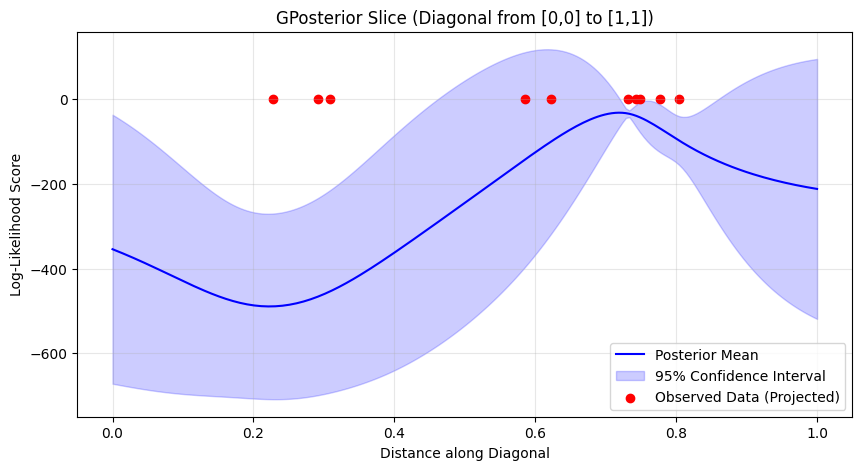

In [14]:
# Posterior slice Plot
# Create a diagonal slice from [0,0] to [1,1]
n_points = 200
line_coords = np.linspace(0, 1, n_points)
X_slice = np.c_[line_coords, line_coords] # Diagonal slice

# Get mean and standard deviation from the Posterior
mu, sigma = gp.predict(X_slice, return_std=True)

plt.figure(figsize=(10, 5))

# Plot the Mean prediction
plt.plot(line_coords, mu, 'b-', label='Posterior Mean')

# Plot the Confidence Interval (95% confidence = 1.96 * sigma)
plt.fill_between(line_coords, 
                 mu - 1.96*sigma, 
                 mu + 1.96*sigma, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')

# Project existing data points onto this diagonal (for visualization)
# We calculate their distance from [0,0] to place them on the X-axis
dist = np.sqrt(np.sum(X**2, axis=1)) / np.sqrt(2)
plt.scatter(dist, y, c='red', label='Observed Data (Projected)')

plt.title('GPosterior Slice (Diagonal from [0,0] to [1,1])')
plt.xlabel('Distance along Diagonal')
plt.ylabel('Log-Likelihood Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

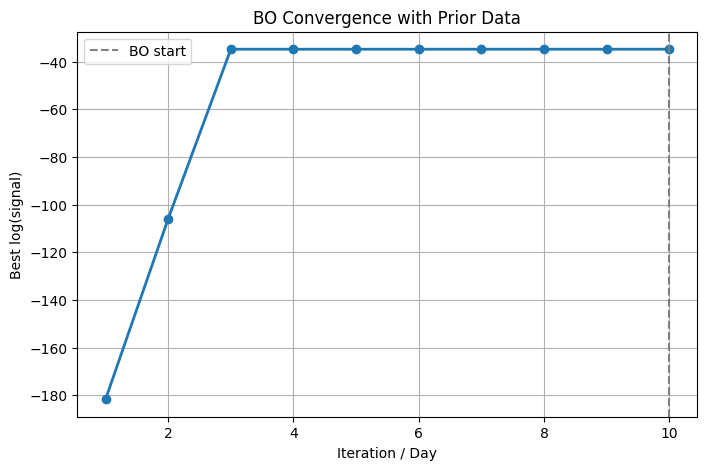

In [15]:
# log_y_observed = np.array([
#     -690.775528,
#     -284.314051,
#     -185.226580,
#     -181.624565,
#     -108.694731,
#     -105.886371,
#     -100.827106,
#     -91.173210,
#     -34.798730,
#     -100.827106   # week 1
# ])

log_y_observed = y_log
iterations = np.arange(1, len(log_y_observed) + 1)
best_log_y = np.maximum.accumulate(log_y_observed)

bo_start_idx = 9  # zero-based index of first BO point

plt.figure(figsize=(8,5))
plt.plot(iterations, best_log_y, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

plt.xlabel("Iteration / Day")
plt.ylabel("Best log(signal)")
plt.title("BO Convergence with Prior Data")
plt.grid(True)
plt.legend()

plt.show()
